# 03 — Linear Spaces

This notebook follows §§1.3–2.3 of Borde and Bronstein, *Mathematical Foundations of Geometric Deep Learning*:

- §1.3 — Vector Spaces
- §2.1 — Norms and Normed Vector Spaces
- §2.2 — Metrics Induced by Norms and Metric Spaces
- §2.3 — The Inner Product and Inner Product Spaces

We put these sections together because they form a natural progression:

$$
\text{vector space}\rightarrow\text{norm}\rightarrow\text{metric}\rightarrow\text{inner product}.
$$

The notebook develops the mathematics first and then connects it computationally to Deep Learning and GDL.

## 1. Vector spaces

A vector space $V$ over a field $\mathbb F$ is a set equipped with vector addition and scalar multiplication satisfying the usual compatibility axioms.

The important conceptual point is that a vector is not inherently an arrow or an array of numbers. It is an abstract element of a space in which vectors can be added and multiplied by scalars.

### Example

$$
\mathbb R^n
$$

with ordinary addition and scalar multiplication is a vector space.

### Non-example

$$
\mathbb R_{>0}
$$

is not a vector space over $\mathbb R$: multiplying a positive number by $-1$ leaves the set.

In [1]:
import numpy as np

# NumPy arrays give a convenient coordinate representation of vectors.
u = np.array([1.0, 2.0, 3.0])
v = np.array([-2.0, 1.0, 4.0])

# Vector addition.
print("u + v =", u + v)

# Scalar multiplication.
print("2.5u =", 2.5 * u)


u + v = [-1.  3.  7.]
2.5u = [2.5 5.  7.5]


## 2. Vector-space axioms

For $u,v,w\in V$ and $\alpha,\beta\in\mathbb F$,

$$
u+v=v+u,
\qquad
(u+v)+w=u+(v+w),
$$

there is a zero vector $0$ with $u+0=u$, every $u$ has an additive inverse, and

$$
\alpha(u+v)=\alpha u+\alpha v,
$$

$$
(\alpha+\beta)u=\alpha u+\beta u,
$$

$$
\alpha(\beta u)=(\alpha\beta)u,
\qquad
1u=u.
$$

No notion of length, distance, or angle is required. Those are additional geometric structures.

## 3. Examples of vector spaces

Important examples include

$$
\mathbb R^n,
$$

the matrix space

$$
\mathbb R^{m\times n},
$$

and the function space

$$
\mathcal F(\Omega)=\{f:\Omega\to\mathbb R\},
$$

with pointwise operations

$$
(f+g)(x)=f(x)+g(x),
\qquad
(\alpha f)(x)=\alpha f(x).
$$

### Non-example

The invertible matrices $GL(n,\mathbb R)$ are not a vector space under ordinary addition and scalar multiplication because the zero matrix is not invertible.

In [2]:
# Matrices form a vector space under ordinary addition and scalar multiplication.
A = np.array([[1.0, 2.0], [3.0, 4.0]])
B = np.array([[0.5, -1.0], [2.0, 1.5]])

print("A + B =\n", A + B)
print("\n3A =\n", 3 * A)


A + B =
 [[1.5 1. ]
 [5.  5.5]]

3A =
 [[ 3.  6.]
 [ 9. 12.]]


## 4. Linear combinations, span, independence, and basis

A linear combination is

$$
\alpha_1v_1+\cdots+\alpha_kv_k.
$$

The span of $S\subseteq V$ is

$$
\operatorname{span}(S)
=
\left\{
\sum_{i=1}^{k}\alpha_i v_i
\mid
v_i\in S,\ \alpha_i\in\mathbb F
\right\}.
$$

A set is linearly independent if

$$
\alpha_1v_1+\cdots+\alpha_kv_k=0
$$

implies all coefficients vanish.

A basis is a linearly independent spanning set. Coordinates depend on the chosen basis,
whereas the underlying vector is independent of that choice.

In [3]:
# The standard basis of R^2.
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

# Construct a vector from its coordinates in this basis.
x, y = 3.0, -2.0
v = x * e1 + y * e2

print("v =", v)
print("Coordinates =", [x, y])


v = [ 3. -2.]
Coordinates = [3.0, -2.0]


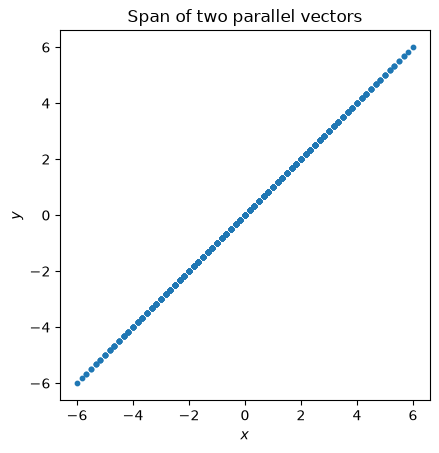

In [4]:
import matplotlib.pyplot as plt

# Two parallel vectors span only a line.
v1 = np.array([1.0, 1.0])
v2 = np.array([2.0, 2.0])

coefficients = np.linspace(-2, 2, 25)
points = np.array([
    a * v1 + b * v2
    for a in coefficients
    for b in coefficients
])

plt.scatter(points[:, 0], points[:, 1], s=10)
plt.gca().set_aspect("equal")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Span of two parallel vectors")
plt.show()


## 5. Linear maps

A map $T:V\to W$ is linear if

$$
T(u+v)=T(u)+T(v),
$$

and

$$
T(\alpha u)=\alpha T(u).
$$

Equivalently,

$$
T(\alpha u+\beta v)=\alpha T(u)+\beta T(v).
$$

For finite-dimensional spaces, a linear map can be represented by a matrix:

$$
T(x)=Ax.
$$

In [5]:
A = np.array([[2.0, 1.0], [0.0, 3.0]])

def T(x):
    # Matrix multiplication implements the linear map.
    return A @ x

u = np.array([1.0, 2.0])
v = np.array([-1.0, 1.0])
alpha, beta = 2.0, -0.5

left = T(alpha * u + beta * v)
right = alpha * T(u) + beta * T(v)

print("Left :", left)
print("Right:", right)
print("Linear?", np.allclose(left, right))


Left : [ 8.5 10.5]
Right: [ 8.5 10.5]
Linear? True


## 6. Tensor spaces

The notes emphasize that practical Deep Learning works extensively with **tensor spaces**.

A scalar, vector, matrix, and higher-order tensor have orders (ranks)

$$
0,1,2,3,\ldots
$$

respectively.

For example,

$$
a=5,
$$

$$
v=
\begin{bmatrix}1\\2\\3\end{bmatrix},
$$

and a matrix is a rank-$2$ tensor.

A tensor with shape $3\times2\times2$ has three indices. These objects are naturally represented by multidimensional arrays in numerical computing.

In [6]:
# NumPy arrays provide a computational representation of tensors.
scalar = np.array(5.0)
vector = np.array([1.0, 2.0, 3.0])
matrix = np.array([[1.0, 2.0], [3.0, 4.0]])
tensor = np.arange(12.0).reshape(3, 2, 2)

print("Scalar:", scalar.shape)
print("Vector:", vector.shape)
print("Matrix:", matrix.shape)
print("Rank-3 tensor:", tensor.shape)


Scalar: ()
Vector: (3,)
Matrix: (2, 2)
Rank-3 tensor: (3, 2, 2)


## 7. Einstein notation and tensor contraction

Repeated indices can denote summation:

$$
u_iv_i=\sum_i u_iv_i.
$$

A matrix-vector product is

$$
M_{ij}v_j=u_i,
$$

and a tensor contraction can be

$$
T_{ijk}v_j=M_{ik}.
$$

Tensor contraction is fundamental in computational mathematics and appears naturally in
neural-network operations.

In [7]:
# `einsum` performs an explicit tensor contraction.
T = np.arange(24.0).reshape(3, 2, 4)
v = np.array([1.0, 2.0])

# Contract the second index of T against v.
M = np.einsum("ijk,j->ik", T, v)

print("T shape:", T.shape)
print("M shape:", M.shape)


T shape: (3, 2, 4)
M shape: (3, 4)


# Part II — Geometric and Analytical Structures

We now add geometric structure to vector spaces:

$$
\boxed{
\text{vector space}
\rightarrow
\text{normed vector space}
\rightarrow
\text{metric space}
\rightarrow
\text{inner-product space}
}.
$$

## 8. Norms

A norm is a map

$$
\|\cdot\|:V\to\mathbb R
$$

satisfying

$$
\|u\|\ge0,
\qquad
\|u\|=0\Longleftrightarrow u=0,
$$

$$
\|\alpha u\|=|\alpha|\|u\|,
$$

and

$$
\|u+v\|\le\|u\|+\|v\|.
$$

A vector space equipped with a norm is a normed vector space.

## 9. $L_p$ norms

For $u\in\mathbb R^n$,

$$
\|u\|_p=
\left(\sum_i|u_i|^p\right)^{1/p}.
$$

Important cases are

$$
\|u\|_1=\sum_i|u_i|,
\qquad
\|u\|_2=\sqrt{\sum_i u_i^2},
$$

and

$$
\|u\|_\infty=\max_i|u_i|.
$$

For functions,

$$
\|f\|_p=
\left(\int_\Omega|f(x)|^p\,dx\right)^{1/p}.
$$

In [8]:
u = np.array([3.0, -4.0])

# Compare three standard norms.
print("L1   =", np.linalg.norm(u, ord=1))
print("L2   =", np.linalg.norm(u, ord=2))
print("Linf =", np.linalg.norm(u, ord=np.inf))


L1   = 7.0
L2   = 5.0
Linf = 4.0


<>:17: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
/var/folders/r_/bxbypgqs0d7fswkmwbxx1ktr0000gn/T/ipykernel_43375/985342251.py:17: SyntaxWarning: invalid escape sequence '\i'
  plt.plot(xinf, yinf, label="$L_\infty$")


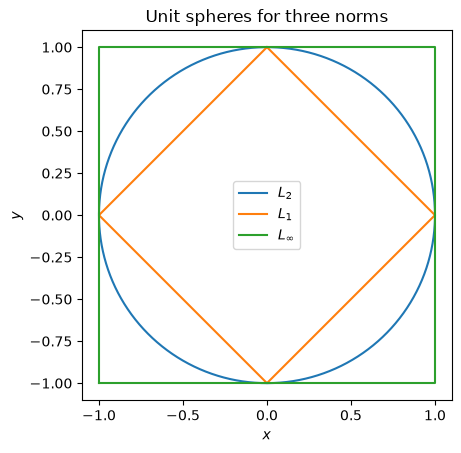

In [9]:
# Visualize the unit boundaries of the L1, L2, and Linf norms in R^2.
theta = np.linspace(0, 2 * np.pi, 1000)

# L2 unit circle.
x2, y2 = np.cos(theta), np.sin(theta)

# L1 unit diamond.
x1 = np.array([0, 1, 0, -1, 0])
y1 = np.array([1, 0, -1, 0, 1])

# Linf unit square.
xinf = np.array([-1, 1, 1, -1, -1])
yinf = np.array([-1, -1, 1, 1, -1])

plt.plot(x2, y2, label="$L_2$")
plt.plot(x1, y1, label="$L_1$")
plt.plot(xinf, yinf, label="$L_\infty$")
plt.gca().set_aspect("equal")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Unit spheres for three norms")
plt.legend()
plt.show()


## 10. Norms in machine learning

Norms measure magnitude and error. For a residual

$$
r=\hat y-y,
$$

we can use

$$
\|r\|_1,\qquad \|r\|_2,\qquad \|r\|_\infty.
$$

They also appear in regularization, for example

$$
\lambda\|\theta\|_2^2
$$

or

$$
\lambda\|\theta\|_1.
$$

The choice of norm therefore changes the geometry of an optimization problem.

## 11. Metrics

A metric is a map

$$
d:X\times X\to\mathbb R
$$

satisfying

$$
d(x,y)\ge0,
$$

$$
d(x,y)=0\Longleftrightarrow x=y,
$$

$$
d(x,y)=d(y,x),
$$

and

$$
d(x,z)\le d(x,y)+d(y,z).
$$

A norm induces a metric by

$$
d(u,v)=\|u-v\|.
$$

Hence every normed vector space is a metric space, but not every metric space is a vector
space or a normed vector space.

In [10]:
u = np.array([1.0, 2.0])
v = np.array([4.0, 6.0])

# The Euclidean metric is induced by the L2 norm.
print("d(u,v) =", np.linalg.norm(u - v))


d(u,v) = 5.0


### Example and non-example

The Euclidean metric

$$
d_2(u,v)=\|u-v\|_2
$$

is a metric.

In contrast,

$$
d(u,v)=|u_1-v_1|
$$

where $u=(u_1, u_2)$ and $v=(v_1, v_2)$ on $\mathbb R^2$ is not a metric because

$$
d((0,0),(0,1))=0
$$

although the points are distinct.

## 12. Pseudo-metrics, quasi-metrics, and Hausdorff distance

A pseudo-metric relaxes identity of indiscernibles.

A quasi-metric may relax the triangle inequality, for example

$$
d(x,z)\le C(d(x,y)+d(y,z)).
$$

For subsets $A,B$ of a metric space, the Hausdorff distance is

$$
d_H(A,B)=
\max\left\{
\sup_{a\in A}\inf_{b\in B}d(a,b),
\sup_{b\in B}\inf_{a\in A}d(a,b)
\right\}.
$$

It is useful for comparing shapes, curves, and point clouds.

In [11]:
def hausdorff_distance(A, B):
    # Compute the Hausdorff distance for two finite point clouds.
    A, B = np.asarray(A), np.asarray(B)

    # Compute all pairwise Euclidean distances.
    distances = np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2)

    # Compute the two directed distances.
    A_to_B = np.max(np.min(distances, axis=1))
    B_to_A = np.max(np.min(distances, axis=0))

    return max(A_to_B, B_to_A)

A = np.array([[0, 0], [1, 0], [2, 0]], dtype=float)
B = np.array([[0, 1], [1, 1], [2, 1]], dtype=float)

print("Hausdorff distance:", hausdorff_distance(A, B))


Hausdorff distance: 1.0


## 13. Inner products

For a real vector space, an inner product

$$
\langle\cdot,\cdot\rangle:V\times V\to\mathbb R
$$

is linear, symmetric,

$$
\langle u,v\rangle=\langle v,u\rangle,
$$

and positive definite.

For complex vector spaces, symmetry becomes conjugate symmetry.

The standard inner product on $\mathbb R^n$ is

$$
\langle u,v\rangle=u^\top v=\sum_i u_iv_i.
$$

In [12]:
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, -1.0, 2.0])

# The Euclidean inner product is the dot product.
print("<u,v> =", np.dot(u, v))


<u,v> = 8.0


## 14. Inner products induce norms

Every inner product induces a norm:

$$
\|u\|=\sqrt{\langle u,u\rangle}.
$$

The Cauchy–Schwarz inequality is

$$
|\langle u,v\rangle|
\le
\|u\|\|v\|.
$$

The angle between nonzero vectors is defined by

$$
\cos\theta=
\frac{\langle u,v\rangle}{\|u\|\|v\|}.
$$

Not every norm comes from an inner product. In the real case, a norm does so exactly when
it satisfies the parallelogram law

$$
2\|u\|^2+2\|v\|^2
=
\|u+v\|^2+\|u-v\|^2.
$$

Then

$$
\langle u,v\rangle
=
\frac14
\left(
\|u+v\|^2-\|u-v\|^2
\right).
$$

In [13]:
u = np.array([2.0, 1.0])
v = np.array([-1.0, 3.0])

# Verify the parallelogram law for the Euclidean norm.
lhs = 2*np.linalg.norm(u)**2 + 2*np.linalg.norm(v)**2
rhs = np.linalg.norm(u+v)**2 + np.linalg.norm(u-v)**2

print("LHS =", lhs)
print("RHS =", rhs)
print("Holds?", np.isclose(lhs, rhs))


LHS = 30.000000000000007
RHS = 30.0
Holds? True


In [14]:
# The L1 norm does not satisfy the parallelogram law.
u = np.array([1.0, 0.0])
v = np.array([0.0, 1.0])

def l1(x):
    # Compute the L1 norm.
    return np.sum(np.abs(x))

lhs = 2*l1(u)**2 + 2*l1(v)**2
rhs = l1(u+v)**2 + l1(u-v)**2

print("LHS =", lhs)
print("RHS =", rhs)
print("Holds?", np.isclose(lhs, rhs))


LHS = 4.0
RHS = 8.0
Holds? False


## 15. Orthogonality and function spaces

Orthogonality is defined by

$$
u\perp v
\quad\Longleftrightarrow\quad
\langle u,v\rangle=0.
$$

The same idea extends to function spaces. For square-integrable functions,

$$
\langle f,g\rangle
=
\int_\Omega f(x)\overline{g(x)}\,dx.
$$

The associated norm is

$$
\|f\|_2=
\left(
\int_\Omega|f(x)|^2\,dx
\right)^{1/2}.
$$

Thus functions can be treated as infinite-dimensional vectors.

In [16]:
import numpy as np
from scipy.integrate import trapezoid

# Approximate the L2 inner product of two functions on [0,1].
x = np.linspace(0, 1, 10000)

f = np.sin(2*np.pi*x)
g = np.cos(2*np.pi*x)

# Numerical integration approximates the continuous inner product.
inner = trapezoid(f * g, x)

print("<f,g> ≈", inner)


<f,g> ≈ 0.0


## 16. Connection to GDL

The orange-box discussions on pages **19, 21, 22, and 25** of the Borde–Bronstein
connect these mathematical structures to machine learning and GDL.

The four themes are:

1. vector spaces and tensors as the natural language of neural-network data;
2. norms as measures of magnitude, error, and regularization geometry;
3. metrics as measures of separation between geometric objects;
4. inner products as the source of similarity, angles, projections, and many tensor
   operations.

The important progression is

$$
\text{algebraic representation}
\rightarrow
\text{geometric structure}
\rightarrow
\text{meaningful computation}.
$$

These connections are central to GDL because the geometry of the representation space
becomes part of the inductive bias of the model.

### 16.1 Tensors and neural-network data — page 19

Deep Learning works extensively with tensors. A typical image batch has shape

$$
(B,C,H,W),
$$

while a sequence representation may have shape

$$
(B,N,D).
$$

These arrays are coordinate representations of elements of structured spaces.

In GDL, the next question is not merely how to store the tensor, but how the tensor
should transform when the underlying geometric object is transformed.

This leads naturally to representations of groups, equivariant features, and geometric
tensor fields.

In [17]:
# A toy image batch: batch, channel, height, width.
images = np.random.randn(8, 3, 32, 32)
print("Image tensor:", images.shape)

# A toy sequence batch: batch, token, embedding dimension.
sequence = np.random.randn(8, 16, 64)
print("Sequence tensor:", sequence.shape)


Image tensor: (8, 3, 32, 32)
Sequence tensor: (8, 16, 64)


### 16.2 Norms and learning — page 21

Norms provide notions of magnitude and error. If

$$
r=\hat y-y,
$$

then $\|r\|_p$ gives an error magnitude.

Norms also occur in parameter regularization, for example

$$
\lambda\|\theta\|_2^2
$$

or

$$
\lambda\|\theta\|_1.
$$

Thus the choice of norm changes the geometry of the optimization problem.

### 16.3 Metrics and geometric data — page 22

A metric measures separation between two objects.

For representations $z_1=f(x_1)$ and $z_2=f(x_2)$,

$$
d(z_1,z_2)
$$

quantifies their separation.

Euclidean distance is appropriate when representations live naturally in a Euclidean
space. GDL often deals with objects for which another metric is more meaningful:
point clouds, shapes, manifolds, graphs, and other structured data.

The metric therefore becomes part of the mathematical meaning of similarity.

### 16.4 Inner products and representation learning — page 25

Inner products provide angles, orthogonality, projections, and similarity.

For embeddings,

$$
\langle u,v\rangle=u^\top v
$$

is a basic similarity measure.

The same operation is central to attention. In scaled dot-product attention,

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}
\left(
\frac{QK^\top}{\sqrt{d_k}}
\right)V,
$$

the entries of $QK^\top$ are query-key inner products.

In GDL, inner products also interact with symmetry representations: one often wants
geometric operations to respect the group action on the representation space.

In [18]:
# A small attention-style calculation: all query-key inner products.
Q = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0]])
K = np.array([[1.0, 1.0, 0.0], [0.0, 1.0, 1.0], [1.0, 0.0, 1.0]])

# Matrix multiplication computes every query-key dot product.
scores = Q @ K.T
print(scores)


[[1. 1. 2.]
 [1. 2. 1.]]


### 16.5 One hierarchy

The four connections can be summarized as

$$
\begin{array}{rcl}
\text{vector spaces} &\longrightarrow& \text{data representations},\\
\text{norms} &\longrightarrow& \text{magnitude and error},\\
\text{metrics} &\longrightarrow& \text{distance and similarity},\\
\text{inner products} &\longrightarrow& \text{angles and interactions}.
\end{array}
$$

The structures are nested in the sense that each additional layer of structure permits
additional mathematical operations:

$$
\text{inner product}
\Rightarrow
\text{norm}
\Rightarrow
\text{metric}.
$$

The converses do not hold in general.

## 17. Summary

The main progression is

$$
\boxed{
\text{vector space}
\rightarrow
\text{norm}
\rightarrow
\text{metric}
\rightarrow
\text{inner product}.
}
$$

A vector space gives algebraic operations. A norm gives magnitude. A metric gives
distance. An inner product gives angles, orthogonality, projections, and similarity.

For GDL, these structures provide the language for representing data and defining
geometrically meaningful computations.

## Exercises

### Exercise 1 — Vector spaces
Give one vector space and one non-example, and identify the failed axiom.

### Exercise 2 — Linear maps
Construct a matrix $A$ and verify

$$
A(\alpha u+\beta v)=\alpha Au+\beta Av.
$$

### Exercise 3 — Bases
Choose a non-standard basis of $\mathbb R^2$ and compute coordinates in that basis.

### Exercise 4 — Norms
Plot the unit balls for $L_1$, $L_2$, and $L_\infty$ and explain their geometry.

### Exercise 5 — Metrics
Give a metric that is not the standard Euclidean metric.

### Exercise 6 — Hausdorff distance
Generate two point clouds and study how their Hausdorff distance changes under
translation, rotation, and deformation.

### Exercise 7 — Inner products
Construct orthogonal vectors and verify

$$
\langle u,v\rangle=0.
$$

### Exercise 8 — Norm versus inner product
Test the parallelogram law for $L_1$, $L_2$, and $L_\infty$.

### Exercise 9 — Tensors
Create tensors of orders $0,1,2,3,4$ and perform contractions with `numpy.einsum`.

### Exercise 10 — GDL
Choose one structure in this notebook and identify a neural-network operation that uses
it. Explain the mathematical role of the structure.

## References

1. **Haitz Sáez de Ocáriz Borde and Michael Bronstein**, *Mathematical Foundations of
Geometric Deep Learning*, arXiv:2508.02723 (2025), §§1.3–2.3.  
https://arxiv.org/abs/2508.02723

2. **Michael M. Bronstein, Joan Bruna, Taco Cohen, and Petar Veličković**,
*Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges*,
arXiv:2104.13478 (2021).  
https://arxiv.org/abs/2104.13478

3. **Michael Artin**, *Algebra*. Pearson / Prentice Hall.


The GDL connections in Section 16 follow the corresponding discussions in §§1.3–2.3
of Borde–Bronstein, including tensor spaces, norms, metrics, and inner products.